In [10]:
# PYTHONPATH=src python3 -m mitochime.deep_learning.train_deep \ 
#   --mode cnn \
#   --train-tsv data/processed/PAIR_train_seq_L150.tsv \
#   --test-tsv  data/processed/PAIR_test_seq_L150.tsv \
#   --L 150 --epochs 30 --batch 128 --lr 0.001 \
#   --seed 42 \
#   --select-best-by f1 \
#   --weight-decay 1e-4 \
#   --out-dir models/deep/cnn_final_L150_seed42 \
#   --reports-dir reports/deep/cnn_final_L150_seed42 \
#   --save-predictions

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# Paths
# --------------------------------------------------
CV_BASE    = Path("../reports/deep/cnn_cv30_L150_seed42")
FINAL_BASE = Path("../reports/deep/cnn_final_L150_seed42_fixedep25")  # update this

FOLDS = [0, 1, 2, 3, 4]

print("CV_BASE exists:", CV_BASE.exists(), CV_BASE)
print("FINAL_BASE exists:", FINAL_BASE.exists(), FINAL_BASE)

CV_BASE exists: True ..\reports\deep\cnn_cv30_L150_seed42
FINAL_BASE exists: True ..\reports\deep\cnn_final_L150_seed42_fixedep25


## cross fold

In [3]:
rows = []
for k in FOLDS:
    p = CV_BASE / f"fold{k}" / "cnn_metrics.json"
    d = json.loads(p.read_text())
    rows.append({
        "fold": k,
        "loss": d["test_loss"],
        "acc": d["accuracy"],
        "prec": d["precision"],
        "rec": d["recall"],
        "f1": d["f1"],
        "auc": d["roc_auc"],
        "n": d["n"],
        "n_pos": d["n_pos"],
        "n_neg": d["n_neg"],
    })

cv_df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)
cv_df

,fold,loss,acc,prec,rec,f1,auc,n,n_pos,n_neg
0,0,0.413652,0.884531,0.850670,0.932813,0.889849,0.946674,6400,3200,3200
1,1,0.447483,0.868594,0.822532,0.940000,0.877352,0.938873,6400,3200,3200
2,2,0.469630,0.851875,0.793688,0.950937,0.865226,0.928304,6400,3200,3200
3,3,0.412574,0.873906,0.834498,0.932813,0.880921,0.938488,6400,3200,3200
4,4,0.478812,0.853079,0.805736,0.930625,0.863689,0.927179,6398,3200,3198


In [4]:
metrics = ["loss", "acc", "prec", "rec", "f1", "auc"]
cv_summary = pd.DataFrame({
    "metric": metrics,
    "mean": [cv_df[m].mean() for m in metrics],
    "std":  [cv_df[m].std(ddof=1) for m in metrics],
})
cv_summary

,metric,mean,std
0,loss,0.444430,0.030776
1,acc,0.866397,0.013949
2,prec,0.821425,0.022599
3,rec,0.937438,0.008337
4,f1,0.875407,0.010997
5,auc,0.935903,0.008145


In [5]:
cv_df.to_csv(CV_BASE / "cnn_cv30_folds.tsv", sep="\t", index=False)
cv_summary.to_csv(CV_BASE / "cnn_cv30_summary.tsv", sep="\t", index=False)
print("Saved:",
      CV_BASE / "cnn_cv30_folds.tsv",
      CV_BASE / "cnn_cv30_summary.tsv")

Saved: ..\reports\deep\cnn_cv30_L150_seed42\cnn_cv30_folds.tsv ..\reports\deep\cnn_cv30_L150_seed42\cnn_cv30_summary.tsv


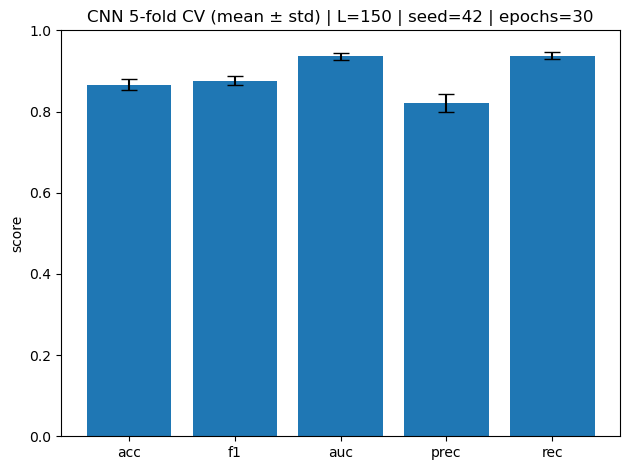

In [6]:
plot_metrics = ["acc", "f1", "auc", "prec", "rec"]
means = [cv_df[m].mean() for m in plot_metrics]
stds  = [cv_df[m].std(ddof=1) for m in plot_metrics]

plt.figure()
plt.bar(plot_metrics, means, yerr=stds, capsize=6)
plt.ylim(0, 1.0)
plt.title("CNN 5-fold CV (mean ± std) | L=150 | seed=42 | epochs=30")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [7]:
logs = []
for k in FOLDS:
    p = CV_BASE / f"fold{k}" / "cnn_training_log.tsv"
    log = pd.read_csv(p, sep="\t")
    log["fold"] = k
    logs.append(log)

log_df = pd.concat(logs, ignore_index=True)

grp = log_df.groupby("epoch", as_index=False).agg(
    train_loss_mean=("train_loss", "mean"),
    train_loss_std=("train_loss", "std"),
    val_loss_mean=("test_loss", "mean"),
    val_loss_std=("test_loss", "std"),
    val_f1_mean=("test_f1", "mean"),
    val_f1_std=("test_f1", "std"),
    val_auc_mean=("test_auc", "mean"),
    val_auc_std=("test_auc", "std"),
)

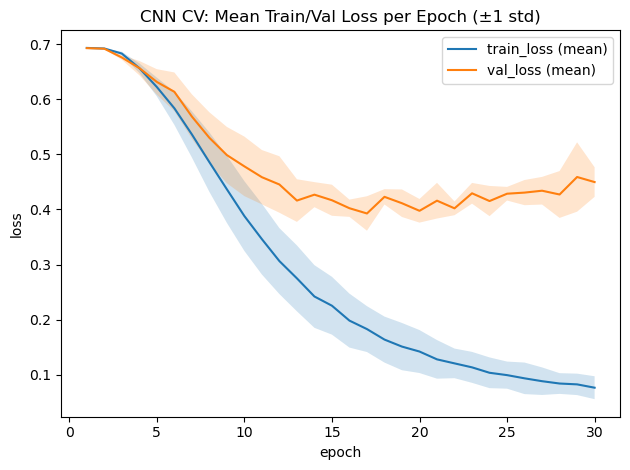

In [8]:
plt.figure()
plt.plot(grp["epoch"], grp["train_loss_mean"], label="train_loss (mean)")
plt.plot(grp["epoch"], grp["val_loss_mean"], label="val_loss (mean)")
plt.fill_between(
    grp["epoch"],
    grp["train_loss_mean"] - grp["train_loss_std"],
    grp["train_loss_mean"] + grp["train_loss_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_loss_mean"] - grp["val_loss_std"],
    grp["val_loss_mean"] + grp["val_loss_std"],
    alpha=0.2
)
plt.title("CNN CV: Mean Train/Val Loss per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

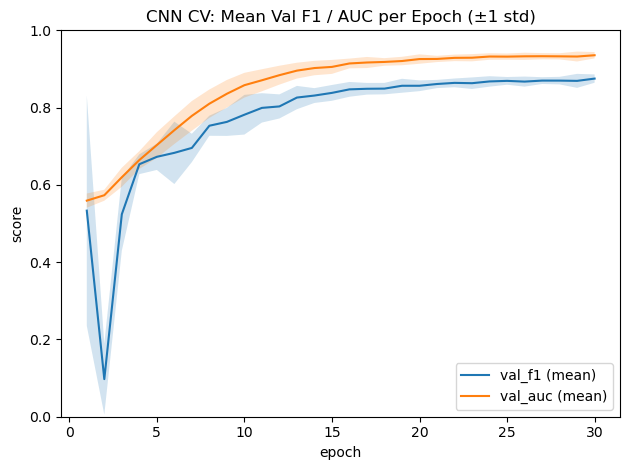

In [9]:
plt.figure()
plt.plot(grp["epoch"], grp["val_f1_mean"], label="val_f1 (mean)")
plt.plot(grp["epoch"], grp["val_auc_mean"], label="val_auc (mean)")
plt.fill_between(
    grp["epoch"],
    grp["val_f1_mean"] - grp["val_f1_std"],
    grp["val_f1_mean"] + grp["val_f1_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_auc_mean"] - grp["val_auc_std"],
    grp["val_auc_mean"] + grp["val_auc_std"],
    alpha=0.2
)
plt.title("CNN CV: Mean Val F1 / AUC per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("score")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

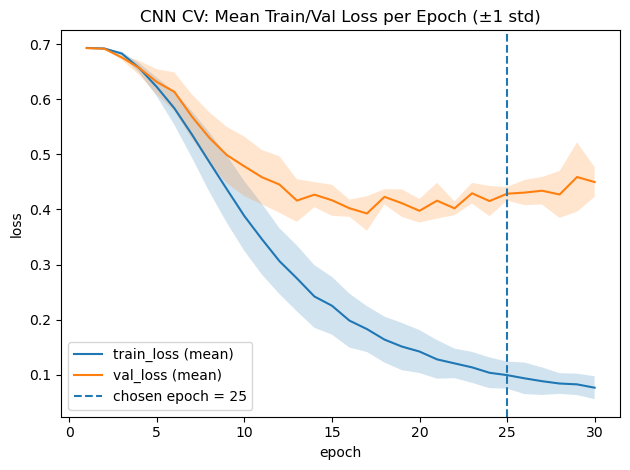

In [10]:
chosen_epoch = 25

plt.figure()
plt.plot(grp["epoch"], grp["train_loss_mean"], label="train_loss (mean)")
plt.plot(grp["epoch"], grp["val_loss_mean"], label="val_loss (mean)")
plt.fill_between(
    grp["epoch"],
    grp["train_loss_mean"] - grp["train_loss_std"],
    grp["train_loss_mean"] + grp["train_loss_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_loss_mean"] - grp["val_loss_std"],
    grp["val_loss_mean"] + grp["val_loss_std"],
    alpha=0.2
)
plt.axvline(chosen_epoch, linestyle="--", label=f"chosen epoch = {chosen_epoch}")
plt.title("CNN CV: Mean Train/Val Loss per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

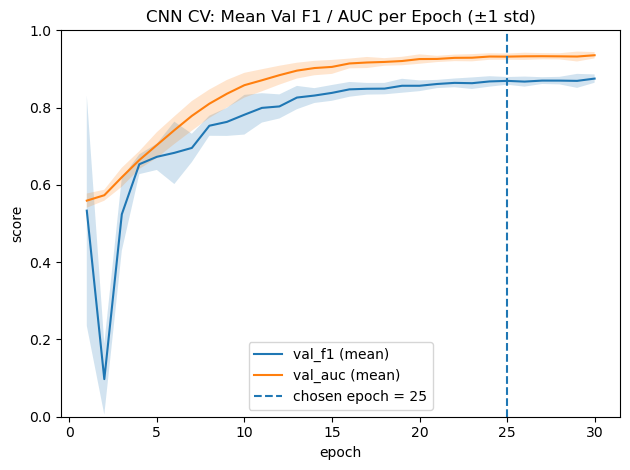

In [11]:
plt.figure()
plt.plot(grp["epoch"], grp["val_f1_mean"], label="val_f1 (mean)")
plt.plot(grp["epoch"], grp["val_auc_mean"], label="val_auc (mean)")
plt.fill_between(
    grp["epoch"],
    grp["val_f1_mean"] - grp["val_f1_std"],
    grp["val_f1_mean"] + grp["val_f1_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_auc_mean"] - grp["val_auc_std"],
    grp["val_auc_mean"] + grp["val_auc_std"],
    alpha=0.2
)
plt.axvline(chosen_epoch, linestyle="--", label=f"chosen epoch = {chosen_epoch}")
plt.title("CNN CV: Mean Val F1 / AUC per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("score")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()

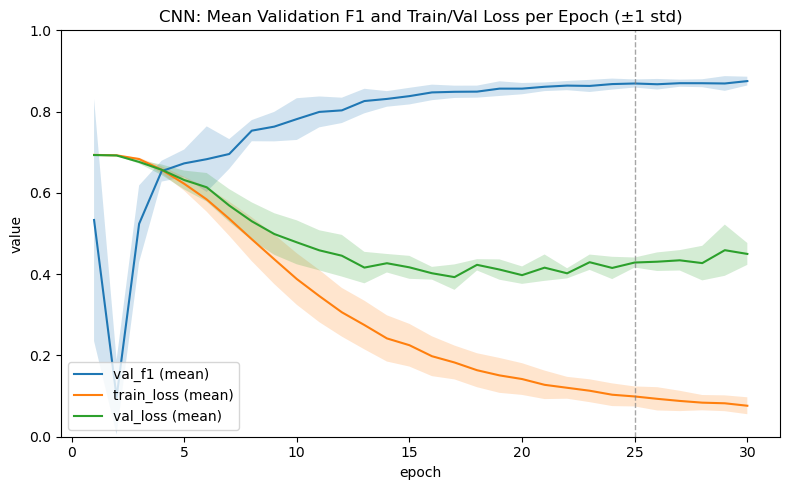

Saved: figures/cnn_cv_f1_loss_epoch25.png


In [16]:
from pathlib import Path
import matplotlib.pyplot as plt

Path("figures").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(grp["epoch"], grp["val_f1_mean"], label="val_f1 (mean)")
plt.plot(grp["epoch"], grp["train_loss_mean"], label="train_loss (mean)")
plt.plot(grp["epoch"], grp["val_loss_mean"], label="val_loss (mean)")

plt.fill_between(
    grp["epoch"],
    grp["val_f1_mean"] - grp["val_f1_std"],
    grp["val_f1_mean"] + grp["val_f1_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["train_loss_mean"] - grp["train_loss_std"],
    grp["train_loss_mean"] + grp["train_loss_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_loss_mean"] - grp["val_loss_std"],
    grp["val_loss_mean"] + grp["val_loss_std"],
    alpha=0.2
)

plt.axvline(x=25, linestyle="--", linewidth=1, color="gray", alpha=0.7)

plt.title("CNN: Mean Validation F1 and Train/Val Loss per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("value")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig("figures/cnn_cv_f1_loss_epoch25.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: figures/cnn_cv_f1_loss_epoch25.png")

## held out test

In [21]:
FINAL_BASE = Path("../reports/deep/cnn_final_L150_seed42_fixedep25")

In [22]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FINAL_BASE = Path("../reports/deep/cnn_final_L150_seed42_fixedep25")

final = json.loads((FINAL_BASE / "cnn_metrics.json").read_text())

final_row = pd.DataFrame([{
    "loss": final["test_loss"],
    "acc": final["accuracy"],
    "prec": final["precision"],
    "rec": final["recall"],
    "f1": final["f1"],
    "auc": final["roc_auc"],
}])

final_row.round(4)

,loss,acc,prec,rec,f1,auc
0,0.3034,0.9092,0.8724,0.9588,0.9135,0.9607


In [23]:
final_row.to_csv(FINAL_BASE / "cnn_final_test_metrics.tsv", sep="\t", index=False)
print("Saved:", FINAL_BASE / "cnn_final_test_metrics.tsv")

Saved: ../reports/deep/cnn_final_L150_seed42_fixedep25/cnn_final_test_metrics.tsv


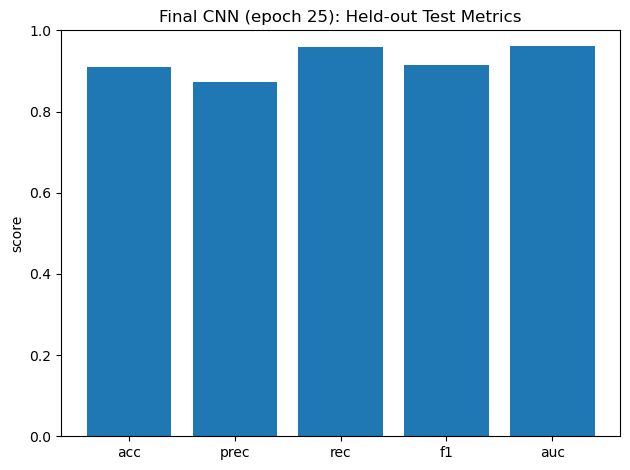

In [24]:
metric_names = ["acc", "prec", "rec", "f1", "auc"]
metric_vals = [final["accuracy"], final["precision"], final["recall"], final["f1"], final["roc_auc"]]

plt.figure()
plt.bar(metric_names, metric_vals)
plt.ylim(0, 1.0)
plt.title("Final CNN (epoch 25): Held-out Test Metrics")
plt.ylabel("score")
plt.tight_layout()
plt.show()

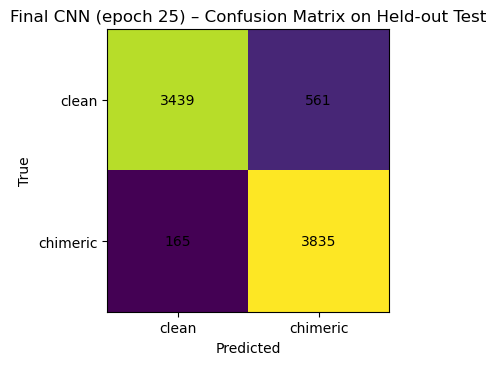

array([[3439,  561],
       [ 165, 3835]])

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

Path("figures").mkdir(parents=True, exist_ok=True)

cm = np.array(final["confusion_matrix"])  # [[TN, FP], [FN, TP]]

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Greys")
plt.title("Final CNN (epoch 25) – Confusion Matrix on Held-out Test")
plt.xticks([0, 1], ["clean", "chimeric"])
plt.yticks([0, 1], ["clean", "chimeric"])
plt.xlabel("Predicted")
plt.ylabel("True")

threshold = cm.max() / 2.0
for (i, j), v in np.ndenumerate(cm):
    text_color = "white" if v > threshold else "black"
    plt.text(j, i, str(v), ha="center", va="center", color=text_color)

plt.tight_layout()
plt.savefig("figures/cnn_confusion.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: figures/cnn_confusion.png")

## compare gb vs cnn

In [26]:
tuned_path = Path("../reports/hparam_tuning_pair_noq/tuned_models_summary.tsv")
tuned = pd.read_csv(tuned_path, sep="\t")

gb = tuned[tuned["model"] == "gradient_boosting_tuned"].iloc[0]

compare = pd.DataFrame([
    {"model": "GradientBoosting (tuned)",
     "acc": gb["test_accuracy"], "prec": gb["test_precision"], "rec": gb["test_recall"],
     "f1": gb["test_f1"], "auc": gb["test_roc_auc"]},
    {"model": "CNN1D (final held-out test)",
     "acc": final["accuracy"], "prec": final["precision"], "rec": final["recall"],
     "f1": final["f1"], "auc": final["roc_auc"]},
])

compare

,model,acc,prec,rec,f1,auc
0,GradientBoosting (tuned),0.809053,0.936771,0.66300,0.77646,0.845858
1,CNN1D (final held-out test),0.909250,0.872384,0.95875,0.91353,0.960690


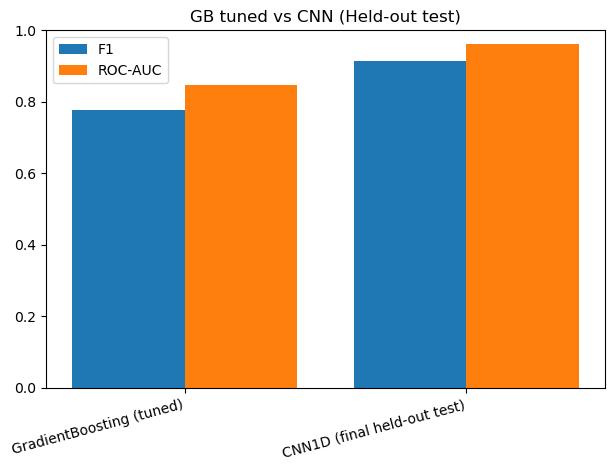

In [27]:
x = np.arange(len(compare))
plt.figure()
plt.bar(x - 0.2, compare["f1"], width=0.4, label="F1")
plt.bar(x + 0.2, compare["auc"], width=0.4, label="ROC-AUC")
plt.xticks(x, compare["model"], rotation=15, ha="right")
plt.ylim(0,1)
plt.title("GB tuned vs CNN (Held-out test)")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
compare.to_csv("../reports/gb_vs_cnn_test.tsv", sep="\t", index=False)
print("Saved:", Path("../reports/gb_vs_cnn_test.tsv"))

Saved: ../reports/gb_vs_cnn_test.tsv


# RNN 

## BI GRU

In [29]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [30]:
# GRU paths
GRU_CV_BASE    = Path("../reports/deep/rnnkmer_bigru_cv30_L150_seed42")
GRU_FINAL_BASE = Path("../reports/deep/rnnkmer_bigru_final_L150_seed42")

In [31]:
import json, pandas as pd
from pathlib import Path

FOLDS = [0,1,2,3,4]
GRU_CV_BASE = Path("../reports/deep/rnnkmer_bigru_cv30_L150_seed42")

rows = []
for k in FOLDS:
    p = GRU_CV_BASE / f"fold{k}" / "rnn_kmer_gru_metrics.json"
    d = json.loads(p.read_text())
    rows.append({
        "fold": k,
        "loss": d["test_loss"],
        "acc": d["accuracy"],
        "prec": d["precision"],
        "rec": d["recall"],
        "f1": d["f1"],
        "auc": d["roc_auc"],
        "n": d["n"],
    })

gru_cv_df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)
gru_cv_df

,fold,loss,acc,prec,rec,f1,auc,n
0,0,0.415488,0.922656,0.895815,0.956562,0.925193,0.967241,6400
1,1,0.398071,0.928906,0.913030,0.948125,0.930247,0.969639,6400
2,2,0.295861,0.932969,0.911006,0.959688,0.934713,0.977993,6400
3,3,0.304658,0.929219,0.923789,0.935625,0.929669,0.974850,6400
4,4,0.284502,0.937637,0.925038,0.952500,0.938568,0.977418,6398


In [32]:
metrics = ["loss", "acc", "prec", "rec", "f1", "auc"]
gru_cv_summary = pd.DataFrame({
    "metric": metrics,
    "mean": [gru_cv_df[m].mean() for m in metrics],
    "std":  [gru_cv_df[m].std(ddof=1) for m in metrics],
})
gru_cv_summary

,metric,mean,std
0,loss,0.339716,0.061943
1,acc,0.930277,0.005534
2,prec,0.913736,0.011810
3,rec,0.950500,0.009382
4,f1,0.931678,0.005119
5,auc,0.973428,0.004781


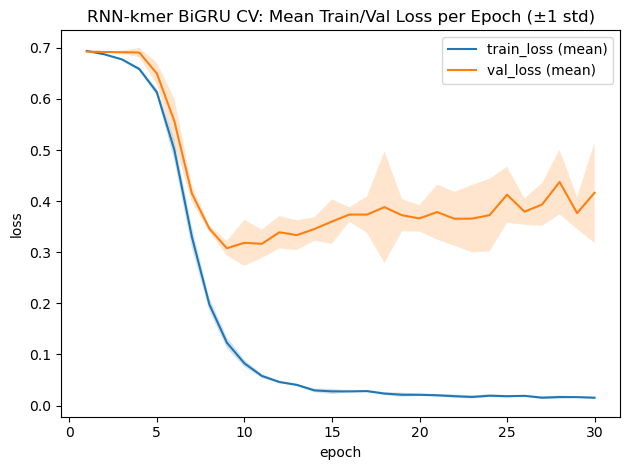

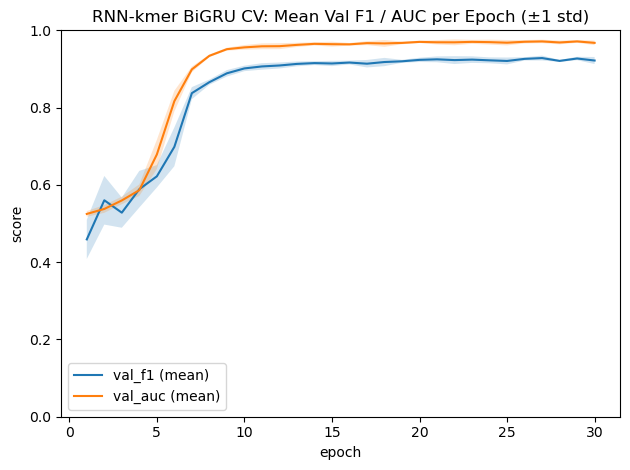

In [33]:
import numpy as np
import matplotlib.pyplot as plt

logs = []
for k in FOLDS:
    p = GRU_CV_BASE / f"fold{k}" / "rnn_kmer_gru_training_log.tsv"
    log = pd.read_csv(p, sep="\t")
    log["fold"] = k
    logs.append(log)

gru_log_df = pd.concat(logs, ignore_index=True)

grp = gru_log_df.groupby("epoch", as_index=False).agg(
    train_loss_mean=("train_loss", "mean"),
    train_loss_std=("train_loss", "std"),
    val_loss_mean=("test_loss", "mean"),
    val_loss_std=("test_loss", "std"),
    val_f1_mean=("test_f1", "mean"),
    val_f1_std=("test_f1", "std"),
    val_auc_mean=("test_auc", "mean"),
    val_auc_std=("test_auc", "std"),
)

plt.figure()
plt.plot(grp["epoch"], grp["train_loss_mean"], label="train_loss (mean)")
plt.plot(grp["epoch"], grp["val_loss_mean"], label="val_loss (mean)")
plt.fill_between(grp["epoch"], grp["train_loss_mean"]-grp["train_loss_std"], grp["train_loss_mean"]+grp["train_loss_std"], alpha=0.2)
plt.fill_between(grp["epoch"], grp["val_loss_mean"]-grp["val_loss_std"], grp["val_loss_mean"]+grp["val_loss_std"], alpha=0.2)
plt.title("RNN-kmer BiGRU CV: Mean Train/Val Loss per Epoch (±1 std)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(grp["epoch"], grp["val_f1_mean"], label="val_f1 (mean)")
plt.plot(grp["epoch"], grp["val_auc_mean"], label="val_auc (mean)")
plt.fill_between(grp["epoch"], grp["val_f1_mean"]-grp["val_f1_std"], grp["val_f1_mean"]+grp["val_f1_std"], alpha=0.2)
plt.fill_between(grp["epoch"], grp["val_auc_mean"]-grp["val_auc_std"], grp["val_auc_mean"]+grp["val_auc_std"], alpha=0.2)
plt.title("RNN-kmer BiGRU CV: Mean Val F1 / AUC per Epoch (±1 std)")
plt.xlabel("epoch"); plt.ylabel("score"); plt.ylim(0,1); plt.legend(); plt.tight_layout(); plt.show()

In [34]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

GRU_FINAL_BASE = Path("../reports/deep/rnnkmer_bigru_final_L150_seed42")
gru_final = json.loads((GRU_FINAL_BASE / "rnn_kmer_gru_metrics.json").read_text())

gru_final_row = pd.DataFrame([{
    "loss": gru_final["test_loss"],
    "acc": gru_final["accuracy"],
    "prec": gru_final["precision"],
    "rec": gru_final["recall"],
    "f1": gru_final["f1"],
    "auc": gru_final["roc_auc"],
}])
gru_final_row.round(4)

,loss,acc,prec,rec,f1,auc
0,0.2432,0.9516,0.9394,0.9655,0.9523,0.9849


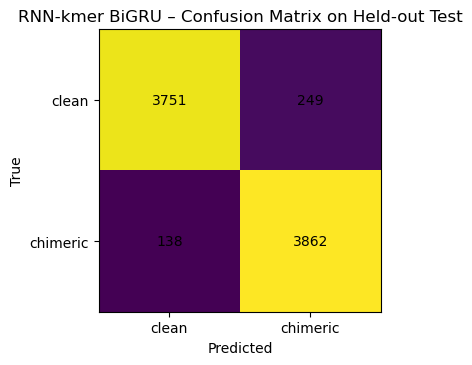

In [35]:
cm = np.array(gru_final["confusion_matrix"])
plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("RNN-kmer BiGRU – Confusion Matrix on Held-out Test")
plt.xticks([0,1], ["clean","chimeric"])
plt.yticks([0,1], ["clean","chimeric"])
plt.xlabel("Predicted"); plt.ylabel("True")
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.tight_layout(); plt.show()

In [36]:
# existing: gb from tuned_models_summary.tsv
# existing: final CNN metrics in `final`

compare3 = pd.DataFrame([
    {"model": "GradientBoosting (tuned)",
     "acc": gb["test_accuracy"], "prec": gb["test_precision"], "rec": gb["test_recall"],
     "f1": gb["test_f1"], "auc": gb["test_roc_auc"]},

    {"model": "CNN1D (held-out test)",
     "acc": final["accuracy"], "prec": final["precision"], "rec": final["recall"],
     "f1": final["f1"], "auc": final["roc_auc"]},

    {"model": "RNN-kmer BiGRU k=4 (held-out test)",
     "acc": gru_final["accuracy"], "prec": gru_final["precision"], "rec": gru_final["recall"],
     "f1": gru_final["f1"], "auc": gru_final["roc_auc"]},
])

compare3

,model,acc,prec,rec,f1,auc
0,GradientBoosting (tuned),0.809053,0.936771,0.66300,0.776460,0.845858
1,CNN1D (held-out test),0.909250,0.872384,0.95875,0.913530,0.960690
2,RNN-kmer BiGRU k=4 (held-out test),0.951625,0.939431,0.96550,0.952287,0.984949


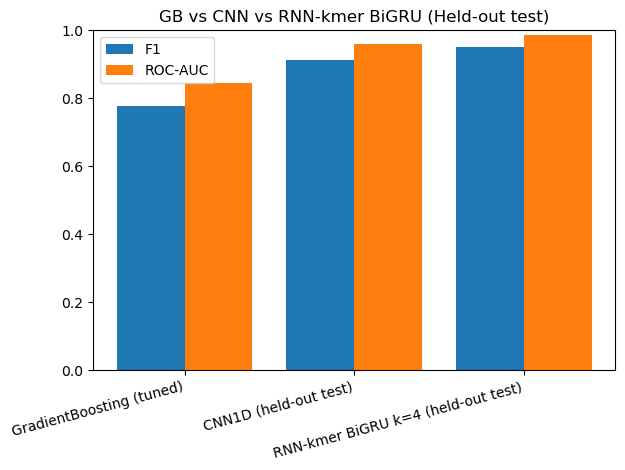

In [37]:
import numpy as np, matplotlib.pyplot as plt

x = np.arange(len(compare3))
plt.figure()
plt.bar(x - 0.2, compare3["f1"],  width=0.4, label="F1")
plt.bar(x + 0.2, compare3["auc"], width=0.4, label="ROC-AUC")
plt.xticks(x, compare3["model"], rotation=15, ha="right")
plt.ylim(0,1)
plt.title("GB vs CNN vs RNN-kmer BiGRU (Held-out test)")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np

pred_path = Path("../reports/deep/rnnkmer_bigru_final_L150_seed42/rnn_kmer_gru_predictions.tsv")
pred = pd.read_csv(pred_path, sep="\t")
pred.head()

,read_id,y_true,y_pred,prob_chimeric
0,NC_039553.1_10002_10566_5:0:0_12:0:0_1009/1,0,1,0.998563
1,NC_039553.1_10002_10566_5:0:0_12:0:0_1009/2,0,0,0.000024
2,NC_039553.1_10015_10487_11:0:0_6:0:0_1ef5/1,0,0,0.000000
3,NC_039553.1_10015_10487_11:0:0_6:0:0_1ef5/2,0,0,0.000626
4,NC_039553.1_10038_10494_5:0:0_5:0:0_20b1/1,0,0,0.000005


In [39]:
def metrics_from_cm(TN, FP, FN, TP):
    acc  = (TP + TN) / (TP + TN + FP + FN)
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0
    f1   = (2*prec*rec)/(prec+rec) if (prec+rec) else 0.0
    fpr  = FP / (FP + TN) if (FP + TN) else 0.0
    fnr  = FN / (FN + TP) if (FN + TP) else 0.0
    return acc, prec, rec, f1, fpr, fnr

y = pred["y_true"].to_numpy().astype(int)
p = pred["prob_chimeric"].to_numpy().astype(float)

thresholds = np.linspace(0.0, 1.0, 201)
rows = []
for t in thresholds:
    yhat = (p >= t).astype(int)
    TN = int(((y==0) & (yhat==0)).sum())
    FP = int(((y==0) & (yhat==1)).sum())
    FN = int(((y==1) & (yhat==0)).sum())
    TP = int(((y==1) & (yhat==1)).sum())
    acc, prec, rec, f1, fpr, fnr = metrics_from_cm(TN,FP,FN,TP)
    rows.append({"thr": t, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "fpr": fpr, "fnr": fnr,
                 "TN": TN, "FP": FP, "FN": FN, "TP": TP})

sweep = pd.DataFrame(rows)
best_f1 = sweep.loc[sweep["f1"].idxmax()]
best_f1

thr        0.285000
acc        0.952375
prec       0.931965
rec        0.976000
f1         0.953474
fpr        0.071250
fnr        0.024000
TN      3715.000000
FP       285.000000
FN        96.000000
TP      3904.000000
Name: 57, dtype: float64

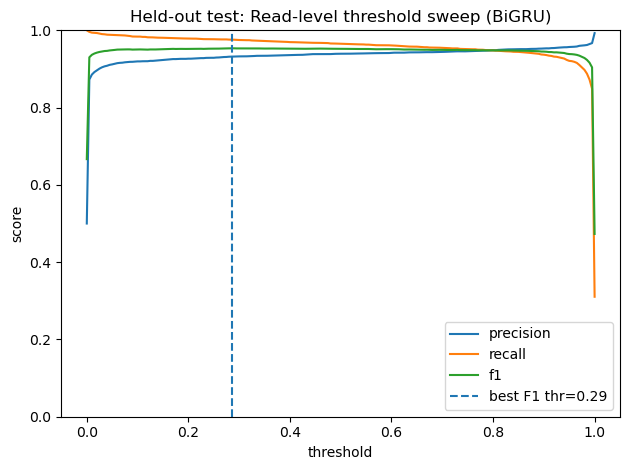

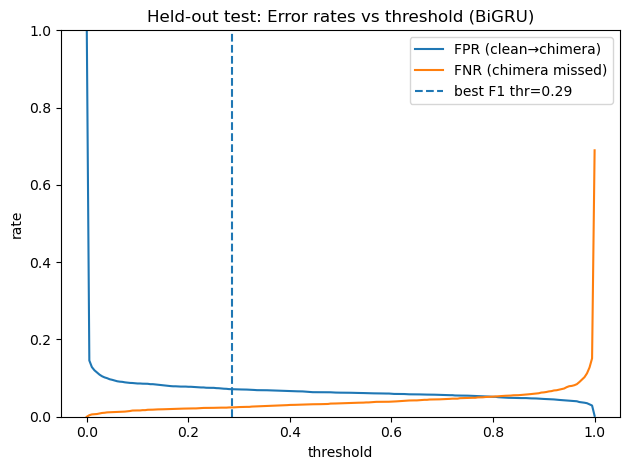

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(sweep["thr"], sweep["prec"], label="precision")
plt.plot(sweep["thr"], sweep["rec"], label="recall")
plt.plot(sweep["thr"], sweep["f1"], label="f1")
plt.axvline(best_f1["thr"], linestyle="--", label=f"best F1 thr={best_f1['thr']:.2f}")
plt.xlabel("threshold"); plt.ylabel("score"); plt.ylim(0,1)
plt.title("Held-out test: Read-level threshold sweep (BiGRU)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(sweep["thr"], sweep["fpr"], label="FPR (clean→chimera)")
plt.plot(sweep["thr"], sweep["fnr"], label="FNR (chimera missed)")
plt.axvline(best_f1["thr"], linestyle="--", label=f"best F1 thr={best_f1['thr']:.2f}")
plt.xlabel("threshold"); plt.ylabel("rate"); plt.ylim(0,1)
plt.title("Held-out test: Error rates vs threshold (BiGRU)")
plt.legend(); plt.tight_layout(); plt.show()

In [41]:
pred["base_id"] = pred["read_id"].str.replace(r"/[12]$", "", regex=True)

pair = pred.groupby("base_id", as_index=False).agg(
    y_true=("y_true", "max"),          # mates share same label; max is safe
    p_max=("prob_chimeric", "max"),
    p_min=("prob_chimeric", "min"),
)

def sweep_pair(prob_col):
    y = pair["y_true"].to_numpy().astype(int)
    p = pair[prob_col].to_numpy().astype(float)
    thresholds = np.linspace(0.0, 1.0, 201)
    rows = []
    for t in thresholds:
        yhat = (p >= t).astype(int)
        TN = int(((y==0) & (yhat==0)).sum())
        FP = int(((y==0) & (yhat==1)).sum())
        FN = int(((y==1) & (yhat==0)).sum())
        TP = int(((y==1) & (yhat==1)).sum())
        acc, prec, rec, f1, fpr, fnr = metrics_from_cm(TN,FP,FN,TP)
        rows.append({"thr": t, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "fpr": fpr, "fnr": fnr})
    return pd.DataFrame(rows)

sweep_or  = sweep_pair("p_max")  # OR rule
sweep_and = sweep_pair("p_min")  # AND rule

best_or  = sweep_or.loc[sweep_or["f1"].idxmax()].to_dict()
best_and = sweep_and.loc[sweep_and["f1"].idxmax()].to_dict()

best_or, best_and

({'thr': 0.99,
  'acc': 0.961,
  'prec': 0.9398854961832062,
  'rec': 0.985,
  'f1': 0.9619140624999999,
  'fpr': 0.063,
  'fnr': 0.015},
 {'thr': 0.015,
  'acc': 0.9845,
  'prec': 0.981610337972167,
  'rec': 0.9875,
  'f1': 0.9845463609172482,
  'fpr': 0.0185,
  'fnr': 0.0125})

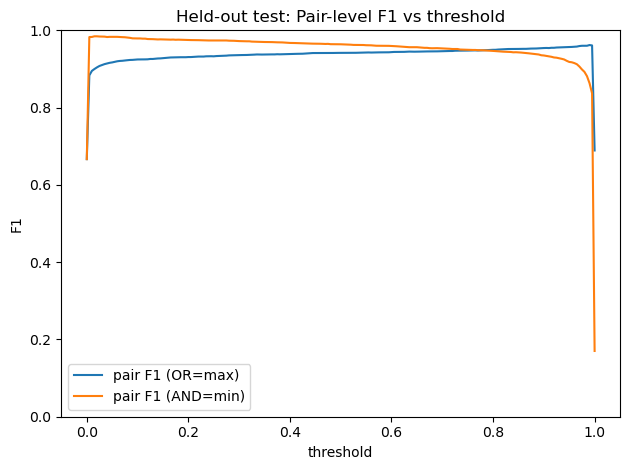

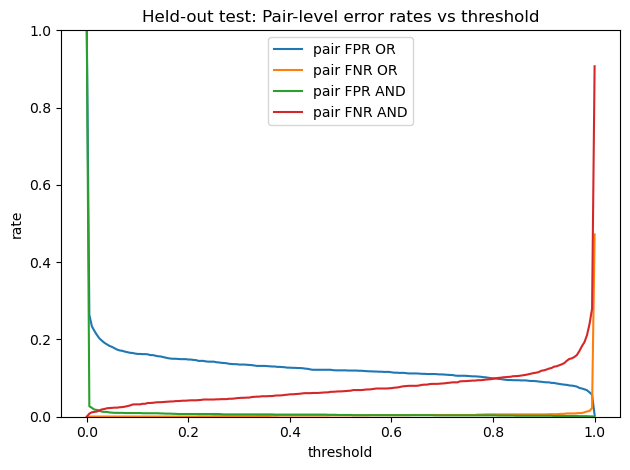

In [42]:
plt.figure()
plt.plot(sweep_or["thr"], sweep_or["f1"], label="pair F1 (OR=max)")
plt.plot(sweep_and["thr"], sweep_and["f1"], label="pair F1 (AND=min)")
plt.xlabel("threshold"); plt.ylabel("F1"); plt.ylim(0,1)
plt.title("Held-out test: Pair-level F1 vs threshold")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(sweep_or["thr"], sweep_or["fpr"], label="pair FPR OR")
plt.plot(sweep_or["thr"], sweep_or["fnr"], label="pair FNR OR")
plt.plot(sweep_and["thr"], sweep_and["fpr"], label="pair FPR AND")
plt.plot(sweep_and["thr"], sweep_and["fnr"], label="pair FNR AND")
plt.xlabel("threshold"); plt.ylabel("rate"); plt.ylim(0,1)
plt.title("Held-out test: Pair-level error rates vs threshold")
plt.legend(); plt.tight_layout(); plt.show()